# What Predicts a High Salary? (Stack Overflow Developer Survey 2025)

This notebook follows the **CRISP-DM** process to analyze the Stack Overflow Developer Survey 2025 and build an interpretable baseline model that predicts whether a respondent earns **above the median annual compensation** (`ConvertedCompYearly`).

**Deliverables**
- A GitHub repository with reproducible analysis
- A blog post summarizing key findings (see Medium link in README)
``

## 1. Business Understanding (CRISP-DM)

**Goal:** Identify which high-level career factors are associated with higher compensation and assess whether a simple model can capture a meaningful signal.

### Business Questions
**Q1. Salary landscape:** What does the compensation distribution look like, and what threshold defines “high salary” in this dataset?  
**Q2. Role & seniority signal:** Which job roles (`DevType`) and employment statuses are most associated with high salary?  
**Q3. Company size effect:** How does organization size (`OrgSize`) relate to the probability of high salary?  
**Q4. Remote work effect:** Does remote/hybrid work show a measurable association with high salary relative to in-person roles?  
**Q5. Education effect:** How does education level (`EdLevel`) relate to high salary outcomes?
``

## 2. Data Understanding (CRISP-DM)

### Dataset
We use:
- `survey_results_public.csv`: survey responses (one respondent per row)
- `survey_results_schema.csv`: data dictionary (column meanings)

### What we inspect
- dataset shape and column coverage
- missing values and target availability
- the distribution of the target (`ConvertedCompYearly`)

In [2]:
import pandas as pd

df = pd.read_csv("survey_results_public.csv", low_memory=False)
schema = pd.read_csv("survey_results_schema.csv")

print("df shape:", df.shape)
print("schema shape:", schema.shape)
display(schema.head())

df shape: (49191, 172)
schema shape: (139, 6)


,qid,qname,question,type,sub,sq_id
0,QID18,TechEndorse_1,What attracts you to a technology or causes yo...,RO,AI integration or AI Agent capabilities,1.0
1,QID18,TechEndorse_2,What attracts you to a technology or causes yo...,RO,Easy-to-use API,2.0
2,QID18,TechEndorse_3,What attracts you to a technology or causes yo...,RO,Robust and complete API,3.0
3,QID18,TechEndorse_4,What attracts you to a technology or causes yo...,RO,Customizable and manageable codebase,4.0
4,QID18,TechEndorse_5,What attracts you to a technology or causes yo...,RO,Reputation for quality,5.0


In [3]:
print("First 20 columns of the dataset:")
print(df.columns[:20])

print("\nSchema columns:")
print(schema.columns)

# common attempt: schema usually has a column with the variable name, like 'column' or 'qname'
possible_key_cols = [c for c in schema.columns if c.lower() in ["column", "qname", "columnname", "name"]]
print("\nPossible key columns in schema:", possible_key_cols)

First 20 columns of the dataset:
Index(['ResponseId', 'MainBranch', 'Age', 'EdLevel', 'Employment',
       'EmploymentAddl', 'WorkExp', 'LearnCodeChoose', 'LearnCode',
       'LearnCodeAI', 'AILearnHow', 'YearsCode', 'DevType', 'OrgSize',
       'ICorPM', 'RemoteWork', 'PurchaseInfluence', 'TechEndorseIntro',
       'TechEndorse_1', 'TechEndorse_2'],
      dtype='object')

Schema columns:
Index(['qid', 'qname', 'question', 'type', 'sub', 'sq_id'], dtype='object')

Possible key columns in schema: ['qname']


In [4]:
# Create dictionary: qname -> question (full question text)
schema_dict = dict(zip(schema["qname"], schema["question"]))

# Examples (choose some columns you have)
for col in ["YearsCodePro", "RemoteWork", "EdLevel", "CompTotal", "DevType"]:
    if col in schema_dict:
        print(f"\n{col} -> {schema_dict[col]}")
    else:
        print(f"\n{col} -> (not in schema, could be technical or from another section)")


YearsCodePro -> (not in schema, could be technical or from another section)

RemoteWork -> Which best describes your current work situation?

EdLevel -> Which of the following best describes the highest level of formal education that you’ve completed? 

CompTotal -> What is your current total <b>annual</b> compensation (salary, bonuses, and perks, before taxes and deductions) in terms of your day-to-day currency?  Please enter a whole number in the box below, without any punctuation.  If you are paid hourly, please estimate an equivalent yearly salary. If you prefer not to answer, please leave the box empty. 

DevType -> Which of the following describes your current job or the job you had for the most time in the past year?


### Notes from initial inspection
- The dataset contains ~49k respondents and 170+ columns.
- Some variables are categorical (e.g., `DevType`, `OrgSize`) and require encoding before modeling.
- The target `ConvertedCompYearly` will be converted to numeric and cleaned in the next step.

In [5]:
# 1) See compensation-related columns
comp_cols = [c for c in df.columns if "Comp" in c or "Salary" in c or "Currency" in c]
comp_cols

['Currency', 'CompTotal', 'AIComplex', 'ConvertedCompYearly']

In [6]:
# 2) See what values are in Currency and if CompFreq exists
if "Currency" in df.columns:
    print("Top currencies:\n", df["Currency"].value_counts().head(10), "\n")

if "CompFreq" in df.columns:
    print("CompFreq values:\n", df["CompFreq"].value_counts(dropna=False), "\n")

# 3) See CompTotal (cleaned)
if "CompTotal" in df.columns:
    print(df["CompTotal"].describe())

Top currencies:
 Currency
EUR European Euro           9618
USD United States dollar    8780
INR Indian rupee            2484
GBP Pound sterling          2047
CAD Canadian dollar         1283
PLN Polish zloty             826
AUD\tAustralian dollar       800
BRL Brazilian real           775
UAH Ukrainian hryvnia        622
SEK\tSwedish krona           601
Name: count, dtype: int64 

count    2.486600e+04
mean     2.234198e+70
std      3.523096e+72
min      0.000000e+00
25%      5.500000e+04
50%      1.050000e+05
75%      2.400000e+05
max      5.555556e+74
Name: CompTotal, dtype: float64


In [7]:
# Base dataset: we keep simple columns to start
base_features = ["YearsCodePro", "EdLevel", "RemoteWork", "OrgSize", "Employment", "DevType"]
base_features = [c for c in base_features if c in df.columns]

target_col = "CompTotal"  # for now
keep_cols = base_features + ["Currency", target_col]
keep_cols = [c for c in keep_cols if c in df.columns]

data = df[keep_cols].copy()

# Convert CompTotal to numeric
data[target_col] = pd.to_numeric(data[target_col], errors="coerce")

# Filter: CompTotal and Currency must exist
data = data.dropna(subset=[target_col, "Currency"])

# Example: keep only USD (you can change it later)
data_usd = data[data["Currency"] == "USD"].copy()

print("Rows total:", data.shape[0])
print("Rows USD:", data_usd.shape[0])
data_usd.head()

Rows total: 24866
Rows USD: 0


,EdLevel,RemoteWork,OrgSize,Employment,DevType,Currency,CompTotal


In [8]:
# Create a column with the clean currency code (only "USD", "EUR", etc.)
data["CurrencyCode"] = data["Currency"].astype(str).str.split().str[0]

# Check that they now appear
print(data["CurrencyCode"].value_counts().head(10))

# Filter USD correctly
data_usd = data[data["CurrencyCode"] == "USD"].copy()

print("Rows total:", data.shape[0])
print("Rows USD:", data_usd.shape[0])
data_usd.head()

CurrencyCode
EUR    7054
USD    6564
GBP    1551
INR    1237
CAD     942
BRL     606
AUD     577
PLN     553
SEK     467
UAH     431
Name: count, dtype: int64
Rows total: 24866
Rows USD: 6564


,EdLevel,RemoteWork,OrgSize,Employment,DevType,Currency,CompTotal,CurrencyCode
4,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",NaN,NaN,"Independent contractor, freelancer, or self-em...",Engineering manager,USD United States dollar,60000.0,USD
5,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",NaN,NaN,"Independent contractor, freelancer, or self-em...","Developer, back-end",USD United States dollar,120000.0,USD
6,Some college/university study without earning ...,NaN,NaN,"Independent contractor, freelancer, or self-em...","Developer, full-stack",USD United States dollar,6240.0,USD
7,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Remote,Less than 20 employees,Employed,"Architect, software or solutions",USD United States dollar,72000.0,USD
8,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Remote,"5,000 to 9,999 employees",Employed,Data engineer,USD United States dollar,70000.0,USD


## 3. Data Preparation (CRISP-DM)

### Target definition
We define **high_salary = 1** if `ConvertedCompYearly` is **above the median**, else 0.
This produces a balanced target (~50/50), reducing misleading accuracy.

### Handling missing values
- Rows with missing target are dropped (supervised learning requires labels).
- For features, we will use imputation:
  - `median` for numeric variables (robust to outliers)
  - `most_frequent` for categorical variables

### Outliers
We clip extreme salaries using the **1st and 99th percentiles** to reduce the impact of outliers.

In [9]:
import numpy as np
import pandas as pd

salary_col = "ConvertedCompYearly"

# Selection of simple features (the ones you are already using)
base_features = ["YearsCodePro", "EdLevel", "RemoteWork", "OrgSize", "Employment", "DevType"]
base_features = [c for c in base_features if c in df.columns]

df_prepared = df[base_features + [salary_col]].copy()

# Convert to numeric
df_prepared[salary_col] = pd.to_numeric(df_prepared[salary_col], errors="coerce")

# Remove nulls and invalid salaries
df_prepared = df_prepared.dropna(subset=[salary_col])
df_prepared = df_prepared[df_prepared[salary_col] > 0].copy()

print("Rows with ConvertedCompYearly valid:", df_prepared.shape[0])
df_prepared.head()

Rows with ConvertedCompYearly valid: 23947


,EdLevel,RemoteWork,OrgSize,Employment,DevType,ConvertedCompYearly
0,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Remote,20 to 99 employees,Employed,"Developer, mobile",61256.0
1,"Associate degree (A.A., A.S., etc.)","Hybrid (some in-person, leans heavy to flexibi...",500 to 999 employees,Employed,"Developer, back-end",104413.0
2,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",NaN,NaN,"Independent contractor, freelancer, or self-em...","Developer, front-end",53061.0
3,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Remote,"10,000 or more employees",Employed,"Developer, back-end",36197.0
4,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",NaN,NaN,"Independent contractor, freelancer, or self-em...",Engineering manager,60000.0


## Q1 — Salary landscape
**What does the compensation distribution look like, and what defines “high salary”?**

We visualize `ConvertedCompYearly` on a log scale due to heavy skew.
Then we define **high_salary** as above the dataset median after clipping p01–p99.


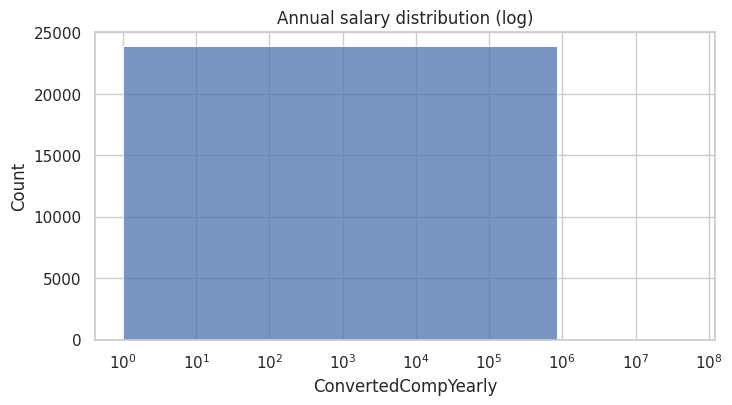

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

plt.figure(figsize=(8,4))
sns.histplot(df_prepared[salary_col], bins=60)
plt.xscale("log")
plt.title("Annual salary distribution (log)")
plt.show()

**Answer (Q1):**
The salary distribution is highly right-skewed. Using the median as the threshold provides a simple, balanced definition of “high salary” for a baseline classification task.

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_compensation_boxplot(
    df,
    x_col,
    y_col="ConvertedCompYearly",
    top_n=None,
    title=None,
    log_scale=True
):
    """
    Plot a boxplot of annual compensation grouped by a categorical feature.

    This helper function supports answering business questions (Q2–Q5) by
    visualizing how `ConvertedCompYearly` varies across categories such as
    developer role, organization size, remote work status, or education level.

    Args:
        df (pd.DataFrame): Input dataframe containing the plotting columns.
        x_col (str): Categorical column used for grouping (e.g., 'DevType', 'OrgSize').
        y_col (str): Numeric compensation column (default: 'ConvertedCompYearly').
        top_n (int | None): If provided, keep only the top N most frequent categories in x_col.
        title (str | None): Plot title. If None, a default title is generated.
        log_scale (bool): If True, use log scale on the y-axis to handle skewed salaries.

    Returns:
        matplotlib.axes.Axes: The Axes object (useful if you want to further customize the plot).
    """
    sns.set(style="whitegrid")
    data = df.copy()

    if top_n is not None:
        top_categories = data[x_col].value_counts().head(top_n).index
        data = data[data[x_col].isin(top_categories)].copy()

    plt.figure(figsize=(12, 5))
    ax = sns.boxplot(data=data, x=x_col, y=y_col)

    if log_scale:
        ax.set_yscale("log")

    ax.set_title(title if title else f"Compensation by {x_col} (log scale)")
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)

    plt.xticks(rotation=45, ha="right")
    plt.show()
    return ax

## 4. Analysis & Visualization (Answering Q2–Q5)

Before training a model, we answer the remaining business questions with descriptive statistics and visualizations.

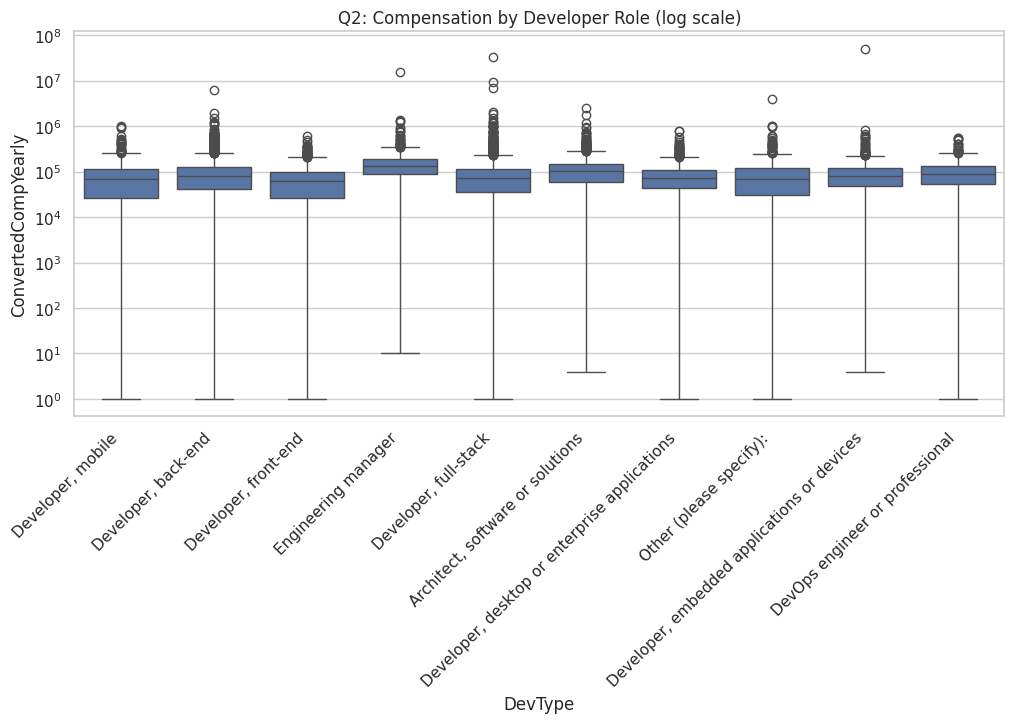

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

df_analysis = df_prepared.copy()
top_roles = df_analysis["DevType"].value_counts().head(10).index
tmp = df_analysis[df_analysis["DevType"].isin(top_roles)].copy()

plt.figure(figsize=(12,5))
sns.boxplot(data=tmp, x="DevType", y="ConvertedCompYearly")
plt.yscale("log")
plt.xticks(rotation=45, ha="right")
plt.title("Q2: Compensation by Developer Role (log scale)")
plt.show()

**Answer (Q2):**
Higher compensation tends to concentrate in senior/leadership roles (e.g., engineering management and executive roles), while entry-level/student categories show lower compensation. This supports the idea that job role and seniority are strongly associated with high salary outcomes.
``

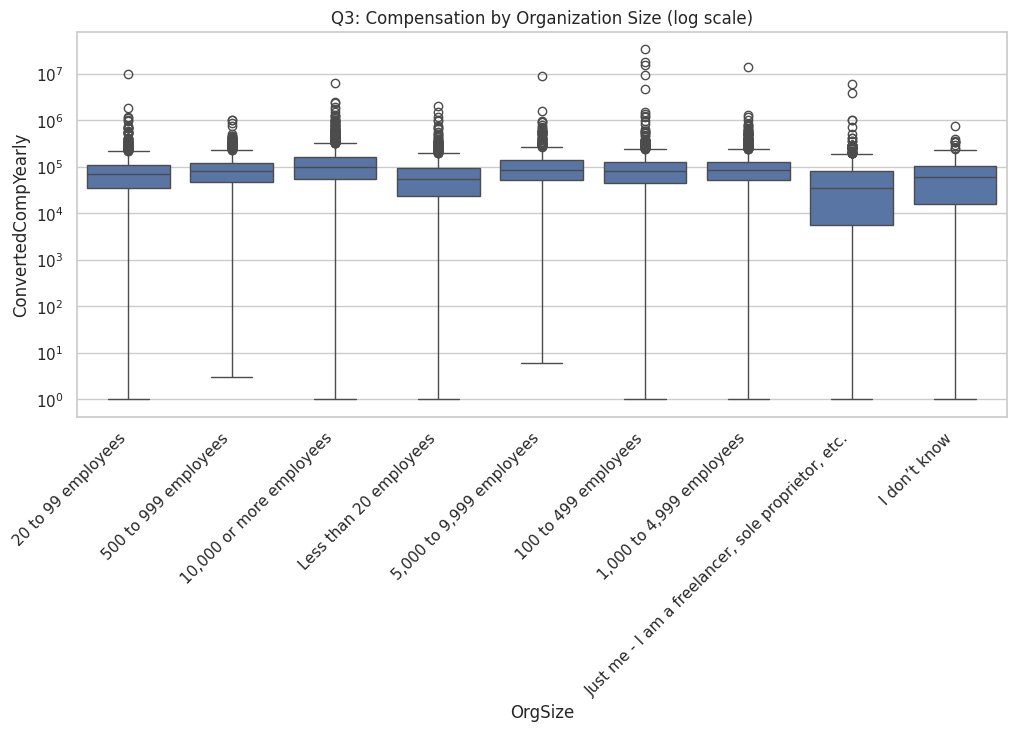

<Axes: title={'center': 'Q3: Compensation by Organization Size (log scale)'}, xlabel='OrgSize', ylabel='ConvertedCompYearly'>

In [13]:
plot_compensation_boxplot(
    df_analysis,
    x_col="OrgSize",
    title="Q3: Compensation by Organization Size (log scale)"
)

**Answer (Q3):**
Compensation generally increases with organization size. Larger organizations (especially 10,000+ employees) show higher salary distributions, suggesting company scale is a meaningful factor in high salary probability.
``

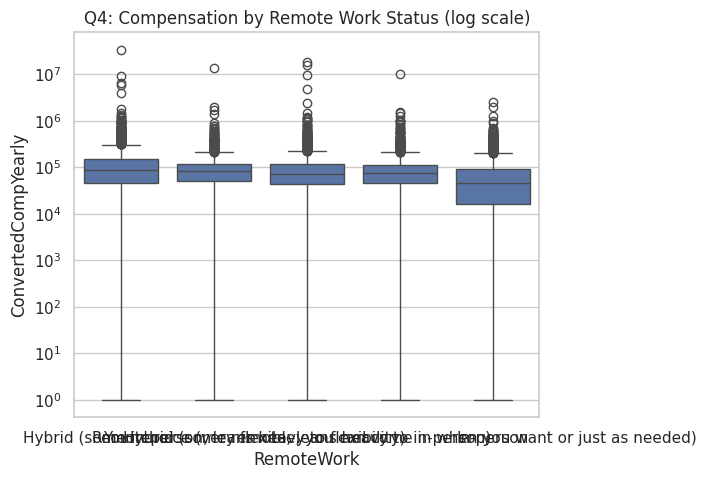

In [14]:
plt.figure(figsize=(6,5))
sns.boxplot(data=df_analysis, x="RemoteWork", y="ConvertedCompYearly")
plt.yscale("log")
plt.title("Q4: Compensation by Remote Work Status (log scale)")
plt.show()

**Answer (Q4):**
Remote/hybrid categories show different compensation distributions compared to in-person roles. While this is an association (not causal), work arrangement appears to relate to compensation in this dataset.
``

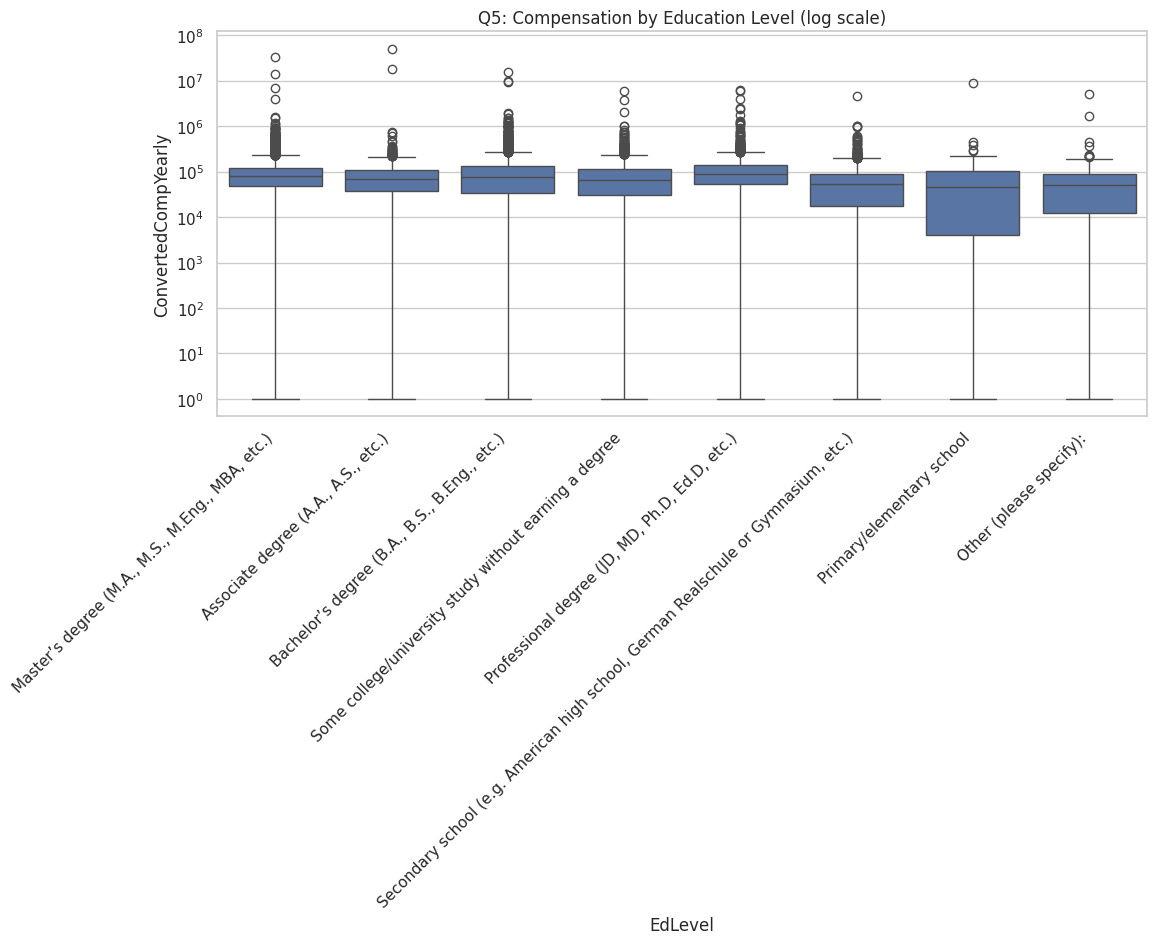

In [15]:
top_ed = df_analysis["EdLevel"].value_counts().head(8).index
tmp = df_analysis[df_analysis["EdLevel"].isin(top_ed)].copy()

plt.figure(figsize=(12,5))
sns.boxplot(data=tmp, x="EdLevel", y="ConvertedCompYearly")
plt.yscale("log")
plt.xticks(rotation=45, ha="right")
plt.title("Q5: Compensation by Education Level (log scale)")
plt.show()

**Answer (Q5):**
Higher education levels (e.g., professional/advanced degrees) tend to align with higher compensation distributions compared to lower education categories, indicating education level is associated with high salary outcomes.

In [16]:
salary_col = "ConvertedCompYearly"

# Percentiles to see extremes (1%, 50%, 99%)
df_prepared[salary_col].quantile([0.01, 0.5, 0.99])
df_prepared[salary_col].describe()

,ConvertedCompYearly
count,2.394700e+04
mean,1.017615e+05
std,4.617569e+05
min,1.000000e+00
25%,3.817100e+04
50%,7.532000e+04
75%,1.205960e+05
max,5.000000e+07


In [17]:
p01 = df_prepared[salary_col].quantile(0.01)
p99 = df_prepared[salary_col].quantile(0.99)

df_model = df_prepared[(df_prepared[salary_col] >= p01) & (df_prepared[salary_col] <= p99)].copy()

print("Rows before:", df_prepared.shape[0])
print("Rows after (p01-p99):", df_model.shape[0])
print("p01:", p01, "| p99:", p99)

Rows before: 23947
Rows after (p01-p99): 23474
p01: 65.0 | p99: 440856.0


In [18]:
median_salary = df_model[salary_col].median()
df_model["high_salary"] = (df_model[salary_col] > median_salary).astype(int)

print("Median:", median_salary)
print(df_model["high_salary"].value_counts(normalize=True))

Median: 75294.0
high_salary
0    0.500085
1    0.499915
Name: proportion, dtype: float64


In [19]:
from sklearn.model_selection import train_test_split

features = ["YearsCodePro", "EdLevel", "RemoteWork", "OrgSize", "Employment", "DevType"]
features = [c for c in features if c in df_model.columns]

X = df_model[features]
y = df_model["high_salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((18779, 5), (4695, 5))

In [20]:
features = [c for c in features if c in df_model.columns]
print("Used features :", features)
print("Number of features:", len(features))

Used features : ['EdLevel', 'RemoteWork', 'OrgSize', 'Employment', 'DevType']
Number of features: 5


## 5. Modeling (CRISP-DM)

### Why One-Hot Encoding?
We use **OneHotEncoder(handle_unknown="ignore")** to avoid imposing an artificial ordering on categories (e.g., Remote vs In-person).

### Why these imputers?
- `median` for numeric variables (robust to outliers)
- `most_frequent` for categorical variables (preserves dominant categories)

### Baseline model
We start with Logistic Regression for interpretability (coefficients show direction of association).
``

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression

# separate numerical/categorical
numeric_features = []
categorical_features = []

for c in X_train.columns:
    if c == "YearsCodePro":
        numeric_features.append(c)
    else:
        categorical_features.append(c)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

model_lr = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000))
])

model_lr.fit(X_train, y_train)

pred = model_lr.predict(X_test)
proba = model_lr.predict_proba(X_test)[:, 1]

print("AUC:", roc_auc_score(y_test, proba))
print("\nClassification report:\n", classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
print("\nConfusion matrix:\n", cm)

AUC: 0.6859239458252189

Classification report:
               precision    recall  f1-score   support

           0       0.64      0.58      0.61      2348
           1       0.62      0.68      0.65      2347

    accuracy                           0.63      4695
   macro avg       0.63      0.63      0.63      4695
weighted avg       0.63      0.63      0.63      4695


Confusion matrix:
 [[1360  988]
 [ 758 1589]]


## 6. Evaluation (CRISP-DM)

We report:
- AUC (threshold-independent ranking)
- classification report (precision/recall/F1)
- confusion matrix (types of errors)

We interpret whether the baseline performance is sufficient and what it misses.

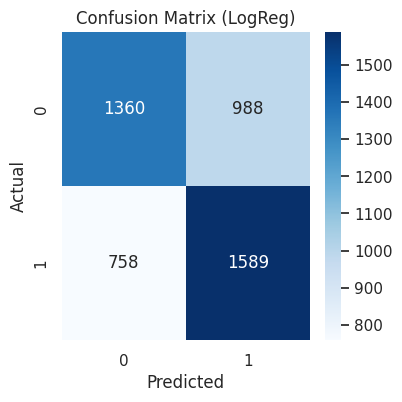

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (LogReg)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Interpretation:**
AUC ~0.69 and accuracy ~0.63 indicate a meaningful but moderate signal using only five high-level features. Errors likely reflect missing context such as country, years of experience, and detailed tech stack.

## 7. Model Interpretation (Coefficients)

Logistic Regression coefficients show which categories are associated with higher or lower odds of being above the median salary, holding other features constant.

In [23]:
# Get column names after one-hot encoding
ohe = model_lr.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
cat_names = ohe.get_feature_names_out(categorical_features)

all_names = np.concatenate([np.array(numeric_features), cat_names])

coefs = model_lr.named_steps["model"].coef_[0]
coef_series = pd.Series(coefs, index=all_names).sort_values()

print("TOP factors that REDUCE high_salary probability:")
display(coef_series.head(10))

print("\nTOP factors that INCREASE high_salary probability:")
display(coef_series.tail(10))

TOP factors that REDUCE high_salary probability:


,0
Employment_Student,-1.699221
DevType_Student,-1.317172
DevType_Academic researcher,-1.217542
"OrgSize_Just me - I am a freelancer, sole proprietor, etc.",-0.977654
DevType_Support engineer or analyst,-0.754739
RemoteWork_In-person,-0.754053
"DevType_Developer, QA or test",-0.738545
OrgSize_Less than 20 employees,-0.612893
EdLevel_Other (please specify):,-0.567487
DevType_Data or business analyst,-0.565214



TOP factors that INCREASE high_salary probability:


,0
DevType_Applied scientist,0.525807
"Employment_Independent contractor, freelancer, or self-employed",0.539595
DevType_Cybersecurity or InfoSec professional,0.546848
"OrgSize_10,000 or more employees",0.571406
Employment_Employed,0.633563
"DevType_Architect, software or solutions",0.639635
"EdLevel_Professional degree (JD, MD, Ph.D, Ed.D, etc.)",0.640284
DevType_Product manager,0.941944
"DevType_Senior executive (C-suite, VP, etc.)",1.163559
DevType_Engineering manager,1.371809


## 8. Deployment (CRISP-DM) — Scenario Analysis

To make the results actionable for a stakeholder, we compare two hypothetical profiles and estimate their probability of being in the high_salary group.


In [24]:
import pandas as pd

used_features = ['EdLevel', 'RemoteWork', 'OrgSize', 'Employment', 'DevType']

profile_a = {
    "EdLevel": "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)",
    "RemoteWork": "In-person",
    "OrgSize": "Less than 20 employees",
    "Employment": "Student",
    "DevType": "Student"
}

profile_b = {
    "EdLevel": "Professional degree (JD, MD, Ph.D, Ed.D, etc.)",
    "RemoteWork": "Remote",
    "OrgSize": "10,000 or more employees",
    "Employment": "Employed",
    "DevType": "Engineering manager"
}

X_scenarios = pd.DataFrame([profile_a, profile_b])[used_features]
probas = model_lr.predict_proba(X_scenarios)[:, 1]

scenario_results = pd.DataFrame({
    "Profile": ["A (lower-salary profile)", "B (higher-salary profile)"],
    "P(high_salary)": probas
})

scenario_results

,Profile,P(high_salary)
0,A (lower-salary profile),0.004566
1,B (higher-salary profile),0.951911


**Scenario takeaway:** This comparison makes the model output actionable for a stakeholder by showing how different profiles translate into different high_salary probabilities (association, not causation).
``

In [25]:
salary_col = "ConvertedCompYearly"

base_features2 = ["YearsCodePro", "EdLevel", "RemoteWork", "OrgSize", "Employment", "DevType"]
base_features2 = [c for c in base_features2 if c in df.columns]

df_prepared = df[base_features2 + [salary_col]].copy()
df_prepared[salary_col] = pd.to_numeric(df_prepared[salary_col], errors="coerce")
df_prepared = df_prepared.dropna(subset=[salary_col])
df_prepared = df_prepared[df_prepared[salary_col] > 0].copy()

# p01-p99 clipping
p01 = df_prepared[salary_col].quantile(0.01)
p99 = df_prepared[salary_col].quantile(0.99)
df_prepared = df_prepared[(df_prepared[salary_col] >= p01) & (df_prepared[salary_col] <= p99)].copy()

# binary target
median_salary = df_prepared[salary_col].median()
df_prepared["high_salary"] = (df_prepared[salary_col] > median_salary).astype(int)

df_prepared.columns

Index(['EdLevel', 'RemoteWork', 'OrgSize', 'Employment', 'DevType',
       'ConvertedCompYearly', 'high_salary'],
      dtype='object')